## 12 - Visualization

This notebook creates charts that tell the story of our research findings.

### Charts we build
1. Sentiment vs 90-day Return (scatter plot) — core finding
2. Market Period Comparison (bar chart) — period trends
3. The Liars Chart — overconfident CEOs who underperformed
4. Hedge Ratio vs Returns (scatter plot) — caution signal
5. Company Hall of Fame and Shame — best vs worst CEOs

### Key finding preview
Cautious CEOs (low sentiment) consistently outperformed.
Confident CEOs (high sentiment) across all market periods.

In [2]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import os

# Set style for all charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,7)
plt.rcParams["font.size"] = 12

# Create output folder for charts
os.makedirs("../reports/charts", exist_ok=True)

# Connect to database and load master table
conn = sqlite3.connect("../data/earnings_research.db")
df = pd.read_sql("SELECT * FROM master_analysis", conn)

# Remove SLB Q2 2023 which had empty transcript
df = df[df["avg_compound"] > 0].copy()

print(f"Loaded {len(df)} records for visualisation")
print(df[["ticker", "quarter", "period", "avg_compound", "return_90d"]].head(10).to_string(index=False))

Loaded 74 records for visualisation
ticker quarter    period  avg_compound  return_90d
  AAPL Q1_2020 Pre-COVID        0.2968      -10.65
   ABT Q1_2020 Pre-COVID        0.2587       19.91
   AMD Q1_2020 Pre-COVID        0.2125       20.50
   BAC Q1_2020 Pre-COVID        0.1907       20.97
   BLK Q1_2020 Pre-COVID        0.2900       33.74
  COST Q1_2020 Pre-COVID        0.1049        5.97
   CRM Q1_2020 Pre-COVID        0.3347       39.74
   CVX Q1_2020 Pre-COVID        0.1566       32.06
   DHR Q1_2020 Pre-COVID        0.2963       37.54
 GOOGL Q1_2020 Pre-COVID        0.2679       28.67


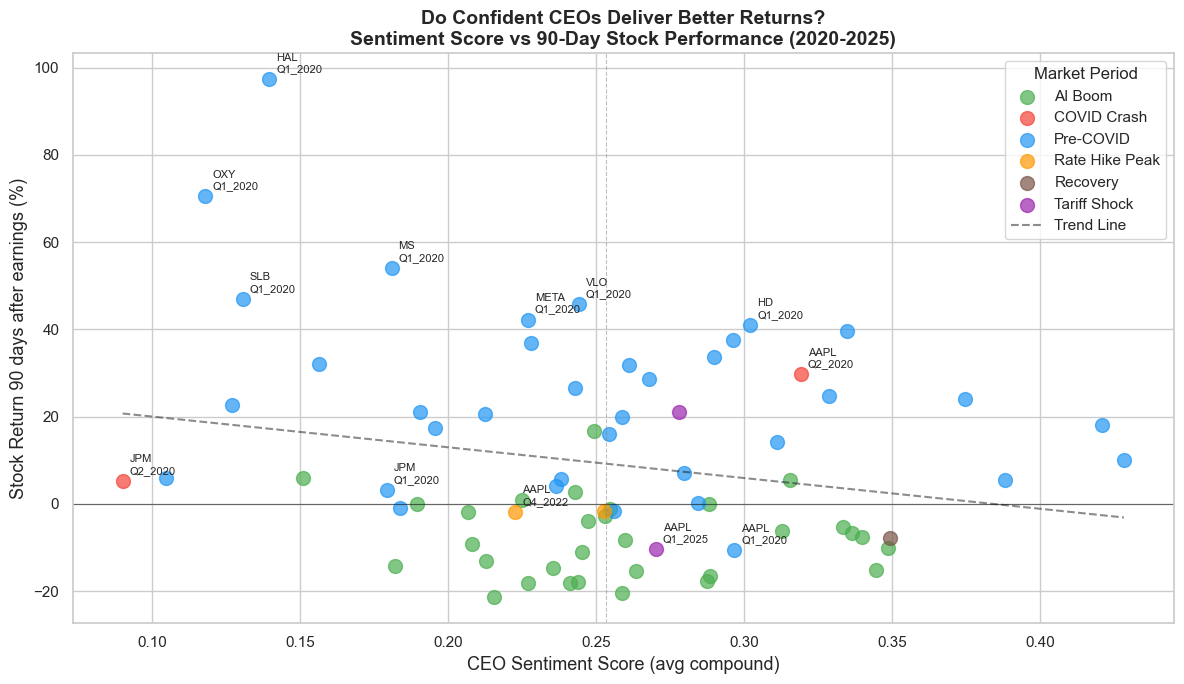

Chart 1 saved!


In [6]:
# Chart 1 - Sentiment vs 90-day return
fig, ax = plt.subplots(figsize=(12,7))

# Colour by market period
colours = {
    "Pre-COVID": "#2196f3",
    "COVID Crash": "#F44336",
    "Rate Hike Peak": "#FF9800",
    "AI Boom": "#4CAF50",
    "Tariff Shock": "#9C27B0",
    "Recovery": "#795548"
}

for period, group in df.groupby("period"):
    ax.scatter(
        group["avg_compound"],
        group["return_90d"],
        label=period,
        color=colours.get(period, "gray"),
        s=100,
        alpha=0.7
    )

# Add trend line
import numpy as np
z = np.polyfit(df["avg_compound"], df["return_90d"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["avg_compound"].min(), df["avg_compound"].max(), 100)
ax.plot(x_line, p(x_line), "k--", alpha=0.5, linewidth=1.5, label="Trend Line")

# Label interesting points
for _, row in df.iterrows():
    if abs(row["return_90d"]) > 40 or row["ticker"] in ["AAPL", "JPM"]:
        ax.annotate(
            f"{row['ticker']}\n{row['quarter']}",
            (row["avg_compound"], row["return_90d"]),
            fontsize=8,
            xytext=(5,5),
            textcoords="offset points"

        )

# Add reference lines
ax.axhline(y=0, color="black", linewidth=0.8, alpha=0.5)
ax.axvline(x=df["avg_compound"].mean(), color="gray", linewidth=0.8, 
           linestyle="--", alpha=0.5)

ax.set_xlabel("CEO Sentiment Score (avg compound)", fontsize=13)
ax.set_ylabel("Stock Return 90 days after earnings (%)", fontsize=13)
ax.set_title("Do Confident CEOs Deliver Better Returns?\nSentiment Score vs 90-Day Stock Performance (2020-2025)", 
             fontsize=14, fontweight="bold")
ax.legend(title="Market Period", loc="upper right")

plt.tight_layout()
plt.savefig("../reports/charts/01_sentiment_vs_return.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved!")

C:\Users\KOMAL\AppData\Local\Temp\ipykernel_87944\2773774537.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(period_stats.index, rotation=30, ha="right")
C:\Users\KOMAL\AppData\Local\Temp\ipykernel_87944\2773774537.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(period_stats.index, rotation=30, ha="right")


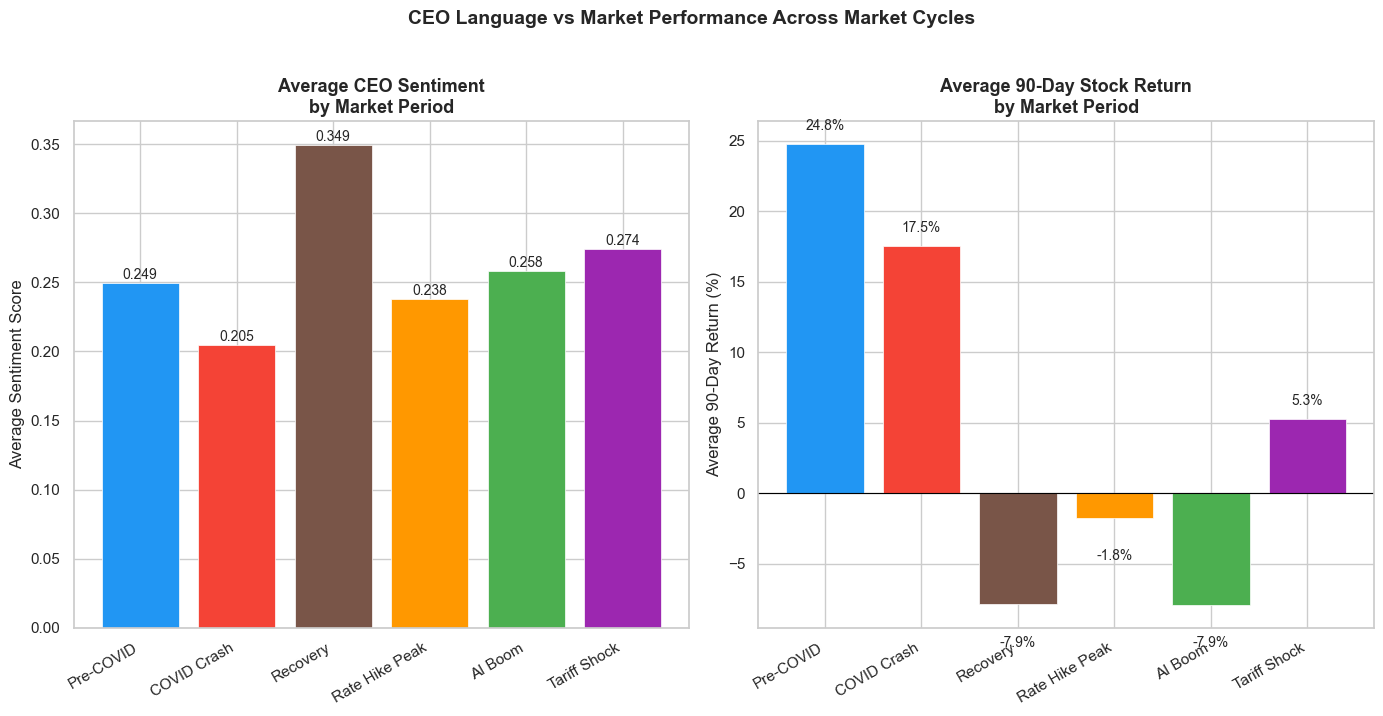

Chart 2 saved!


In [9]:
# Chart 2 — Average Sentiment and Returns by Market Period
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

period_order = ["Pre-COVID", "COVID Crash", "Recovery", 
                "Rate Hike Peak", "AI Boom", "Tariff Shock"]

period_stats = df.groupby("period").agg(
    avg_sentiment=("avg_compound", "mean"),
    avg_return=("return_90d", "mean"),
    count=("ticker", "count")
).reindex([p for p in period_order if p in df["period"].unique()])

# Left chart - Average Sentiment by Period
bars1 = ax1.bar(period_stats.index, period_stats["avg_sentiment"],
                color=[colours.get(p, "gray") for p in period_stats.index],
                edgecolor="white", linewidth=0.5)
ax1.set_title("Average CEO Sentiment\nby Market Period", 
              fontsize=13, fontweight="bold")
ax1.set_ylabel("Average Sentiment Score")
ax1.set_xticklabels(period_stats.index, rotation=30, ha="right")
for bar, val in zip(bars1, period_stats["avg_sentiment"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.3f}", ha="center", fontsize=10)

# Right chart - Average 90-day Return by Period
bars2 = ax2.bar(period_stats.index, period_stats["avg_return"],
                color=[colours.get(p, "gray") for p in period_stats.index],
                edgecolor="white", linewidth=0.5)
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_title("Average 90-Day Stock Return\nby Market Period",
              fontsize=13, fontweight="bold")
ax2.set_ylabel("Average 90-Day Return (%)")
ax2.set_xticklabels(period_stats.index, rotation=30, ha="right")
for bar, val in zip(bars2, period_stats["avg_return"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (1 if val >= 0 else -3),
             f"{val:.1f}%", ha="center", fontsize=10)

plt.suptitle("CEO Language vs Market Performance Across Market Cycles",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/charts/02_period_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved!")

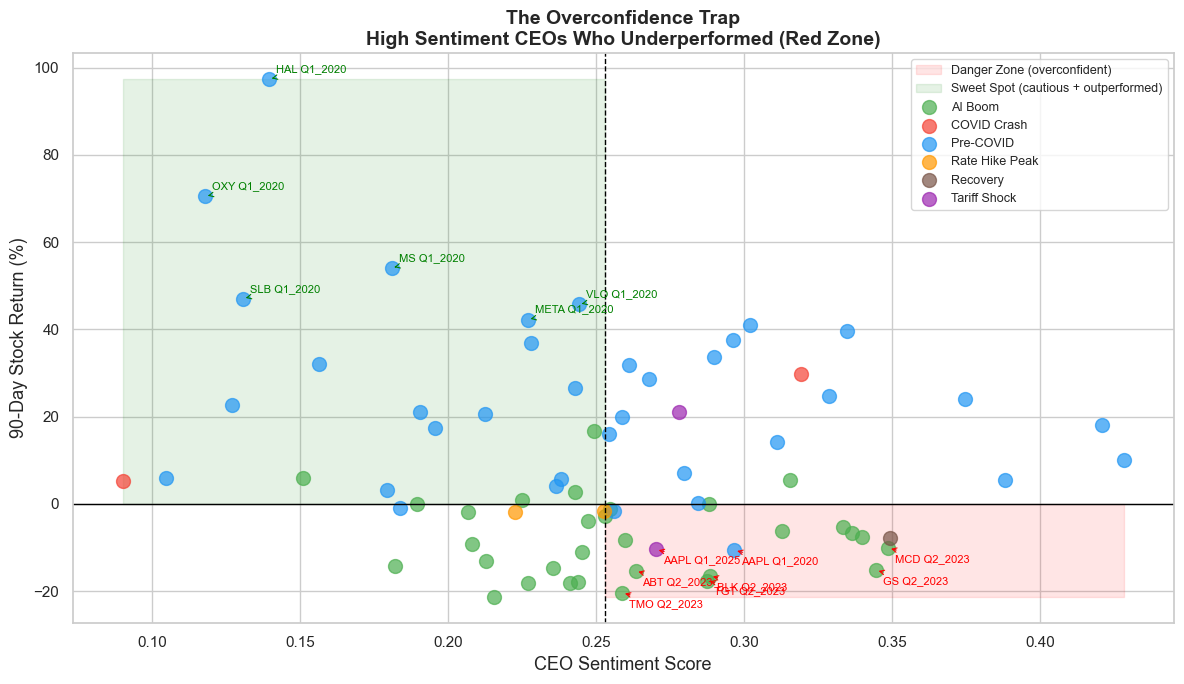

Chart 3 saved!


In [10]:
# Chart 3 — The Liars Chart
# High sentiment + negative returns = overconfident CEOs

fig, ax = plt.subplots(figsize=(12, 7))

# Add quadrant shading
ax.axhline(y=0, color="black", linewidth=1)
ax.axvline(x=df["avg_compound"].median(), color="black", 
           linewidth=1, linestyle="--")

# Shade quadrants
ax.fill_between([df["avg_compound"].median(), df["avg_compound"].max()],
                df["return_90d"].min(), 0,
                alpha=0.1, color="red", label="Danger Zone (overconfident)")
ax.fill_between([df["avg_compound"].min(), df["avg_compound"].median()],
                0, df["return_90d"].max(),
                alpha=0.1, color="green", label="Sweet Spot (cautious + outperformed)")

# Plot all points
for period, group in df.groupby("period"):
    ax.scatter(group["avg_compound"], group["return_90d"],
               label=period, color=colours.get(period, "gray"),
               s=100, alpha=0.7)

# Label the liars - high sentiment, negative returns
liars = df[(df["avg_compound"] > df["avg_compound"].median()) & 
           (df["return_90d"] < -10)]
for _, row in liars.iterrows():
    ax.annotate(f"{row['ticker']} {row['quarter']}",
                (row["avg_compound"], row["return_90d"]),
                fontsize=8, color="red",
                xytext=(5, -10), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color="red", lw=0.8))

# Label the heroes - low sentiment, high returns
heroes = df[(df["avg_compound"] < df["avg_compound"].median()) & 
            (df["return_90d"] > 40)]
for _, row in heroes.iterrows():
    ax.annotate(f"{row['ticker']} {row['quarter']}",
                (row["avg_compound"], row["return_90d"]),
                fontsize=8, color="green",
                xytext=(5, 5), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color="green", lw=0.8))

ax.set_xlabel("CEO Sentiment Score", fontsize=13)
ax.set_ylabel("90-Day Stock Return (%)", fontsize=13)
ax.set_title("The Overconfidence Trap\nHigh Sentiment CEOs Who Underperformed (Red Zone)",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/charts/03_liars_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved!")

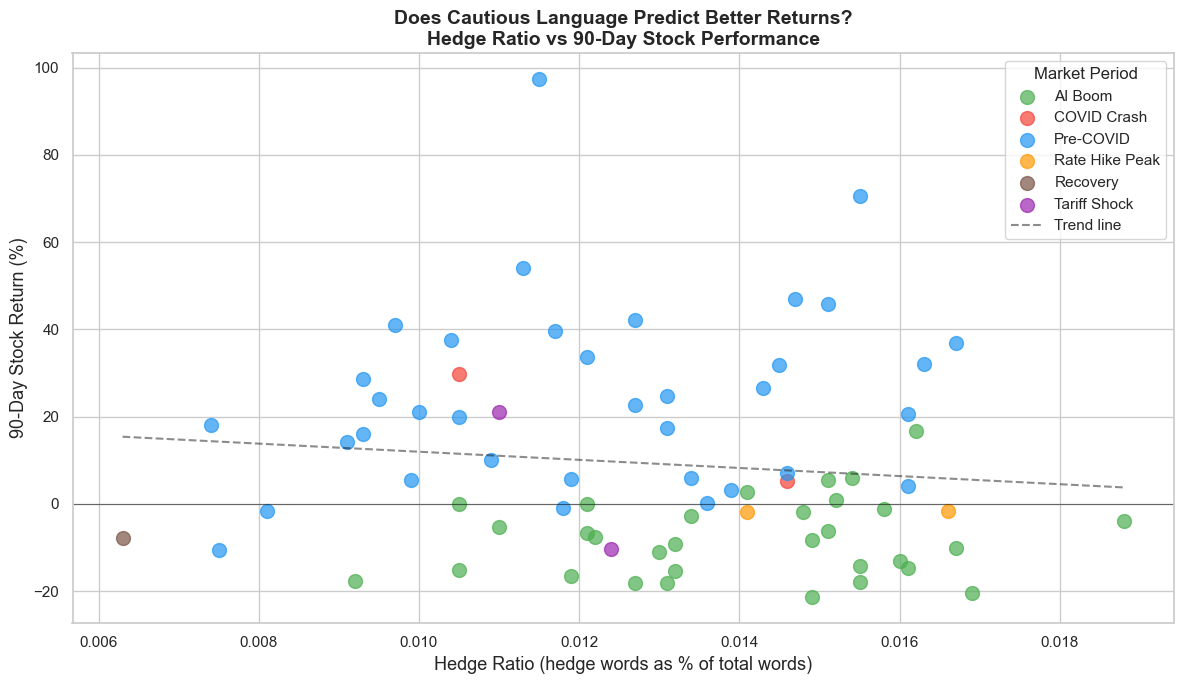

Chart 4 saved!


In [11]:
# Chart 4 — Hedge Ratio vs 90-day Return
fig, ax = plt.subplots(figsize=(12, 7))

for period, group in df.groupby("period"):
    ax.scatter(group["hedge_ratio"], group["return_90d"],
               label=period, color=colours.get(period, "gray"),
               s=100, alpha=0.7)

# Trend line
z = np.polyfit(df["hedge_ratio"], df["return_90d"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["hedge_ratio"].min(), df["hedge_ratio"].max(), 100)
ax.plot(x_line, p(x_line), "k--", alpha=0.5, linewidth=1.5, label="Trend line")

ax.axhline(y=0, color="black", linewidth=0.8, alpha=0.5)

ax.set_xlabel("Hedge Ratio (hedge words as % of total words)", fontsize=13)
ax.set_ylabel("90-Day Stock Return (%)", fontsize=13)
ax.set_title("Does Cautious Language Predict Better Returns?\nHedge Ratio vs 90-Day Stock Performance",
             fontsize=14, fontweight="bold")
ax.legend(title="Market Period", loc="upper right")

plt.tight_layout()
plt.savefig("../reports/charts/04_hedge_vs_return.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved!")

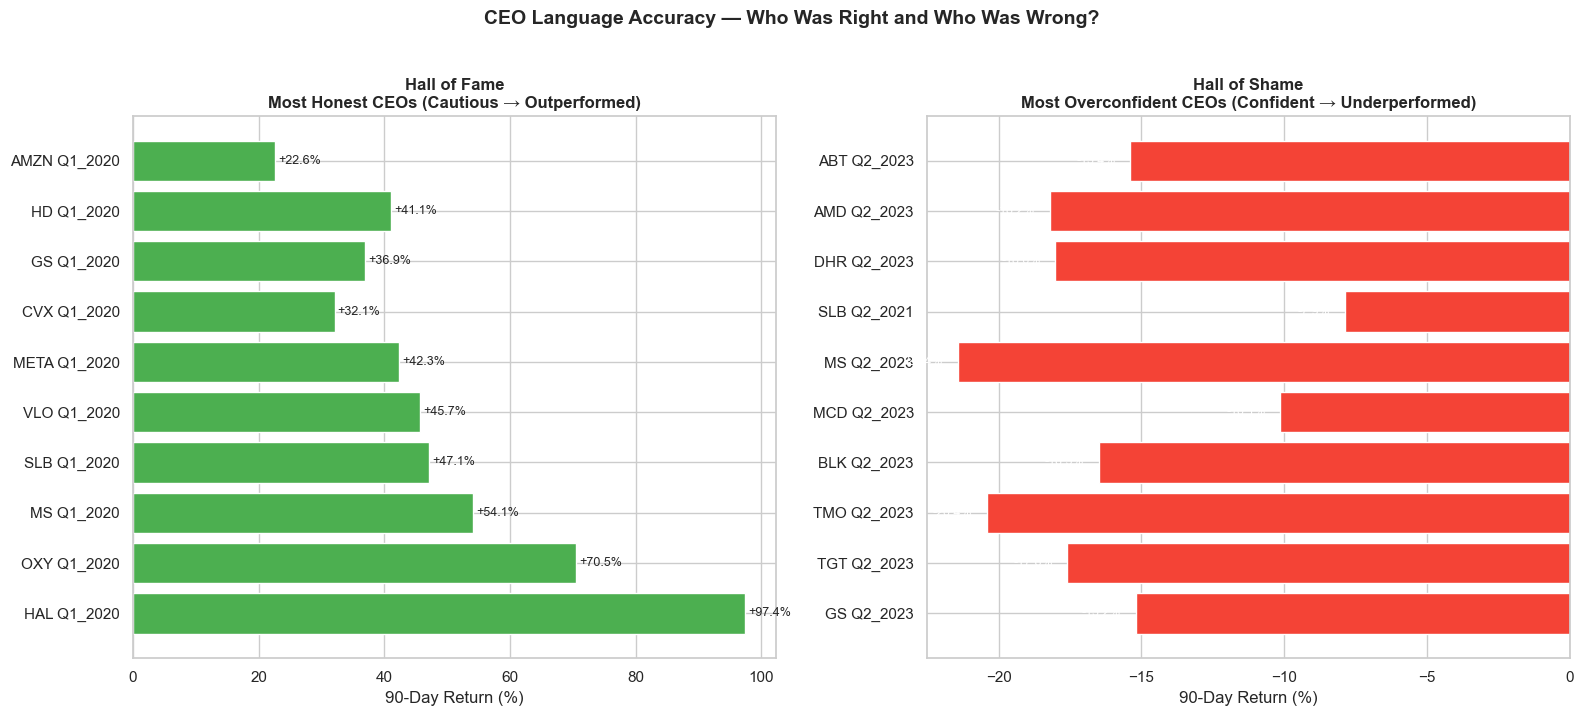

Chart 5 saved!


In [12]:
# Chart 5 — Company Hall of Fame and Shame
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Hall of Fame — lowest sentiment, highest returns (most honest CEOs)
df["accuracy_score"] = df["return_90d"] - (df["avg_compound"] * 100)
hall_of_fame = df.nlargest(10, "accuracy_score")[["ticker", "quarter", "avg_compound", "return_90d"]]
hall_of_shame = df.nsmallest(10, "accuracy_score")[["ticker", "quarter", "avg_compound", "return_90d"]]

# Hall of Fame chart
bars1 = ax1.barh(
    [f"{r['ticker']} {r['quarter']}" for _, r in hall_of_fame.iterrows()],
    hall_of_fame["return_90d"],
    color="#4CAF50", edgecolor="white"
)
ax1.set_title("Hall of Fame\nMost Honest CEOs (Cautious → Outperformed)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("90-Day Return (%)")
for bar, val in zip(bars1, hall_of_fame["return_90d"]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"+{val:.1f}%", va="center", fontsize=9)

# Hall of Shame chart
bars2 = ax2.barh(
    [f"{r['ticker']} {r['quarter']}" for _, r in hall_of_shame.iterrows()],
    hall_of_shame["return_90d"],
    color="#F44336", edgecolor="white"
)
ax2.set_title("Hall of Shame\nMost Overconfident CEOs (Confident → Underperformed)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("90-Day Return (%)")
for bar, val in zip(bars2, hall_of_shame["return_90d"]):
    ax2.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", ha="right", fontsize=9, color="white")

plt.suptitle("CEO Language Accuracy — Who Was Right and Who Was Wrong?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/charts/05_hall_of_fame_shame.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved!")